# Computer Vision
## Exercise Sheet 1: Imaging
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Harsh Kumar
2.
3.
4.
5.


In [6]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [7]:
import cv2 # open cv
import matplotlib.pyplot as plt # plotting tools
import numpy as np # matrix, array operations

from os.path import join # combine different items to a path
from os import getcwd, listdir # shows the current directory, lists items in a directory

# show plots when running cell
%matplotlib inline

## Exercise 1.1
### Loading and displaying images in Python
Download the image `clown.png` from the website of the tutorial. Load
the image in Python via opencv (`cv2.imread`). By default the image is loaded as BGR (blue, green, red), convert the image to gray with `cv2.cvtColor`.
Display the image `plt.imshow`, use the colormap `gray`.

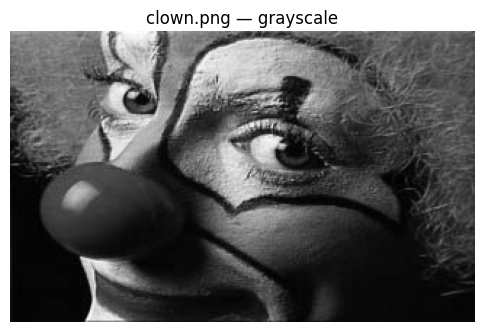

In [12]:
# TODO: define image path
image_path = join(getcwd(), 'data', 'exercise_1', 'clown.png')

# TODO: read image
# cv2.imread loads in BGR order by default
image_bgr = cv2.imread(image_path)

# TODO: convert image to grayscale
# cv2.COLOR_BGR2GRAY converts BGR -> single-channel gray
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# TODO: display image
plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap='gray')
plt.title('clown.png — grayscale')
plt.axis('off')
plt.show()

## Exercise 1.2
### Image gradients
Images are stored as `numpy arrays`, for further computations convert the array to range $[0, 1]$ (`astype`). Define a function `load_gray_normalized` that loads the image, converts it to grayscale and normalizes it.
Compute the image gradients $d_x$ and $d_y$ for the image from the previous assignment. Initialize a simple gradient kernel like $[-1, 0, +1]$ for $d_x$ (`np.zeros`, `np.array`) and filter the image with it (`cv2.filter2D`). Visualize the results using `plt.imshow`. To this end, display the resulting images of both derivatives along `x` and `y` in a single figure (`plt.subplots`).

What do you need to take care of, to be able to visually **compare** the results?
Hint: the problem is related to the range of the pixel values in the two
gradient images. Name the problem and propose a solution to it by using the options of the `plt.imshow`
function.

In [14]:
def load_gray_normalized(image_path):
    """
    Load an image, convert to grayscale, and normalise pixel values to [0, 1].

    Parameters
    ----------
    image_path : str
        Path to the image file.

    Returns
    -------
    np.ndarray  (float64, shape H x W, range [0, 1])
    """
    img = cv2.imread(image_path)                       # BGR uint8
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   # gray uint8
    img_norm = img_gray.astype(np.float64) / 255.0     # normalise -> [0, 1]
    return img_norm

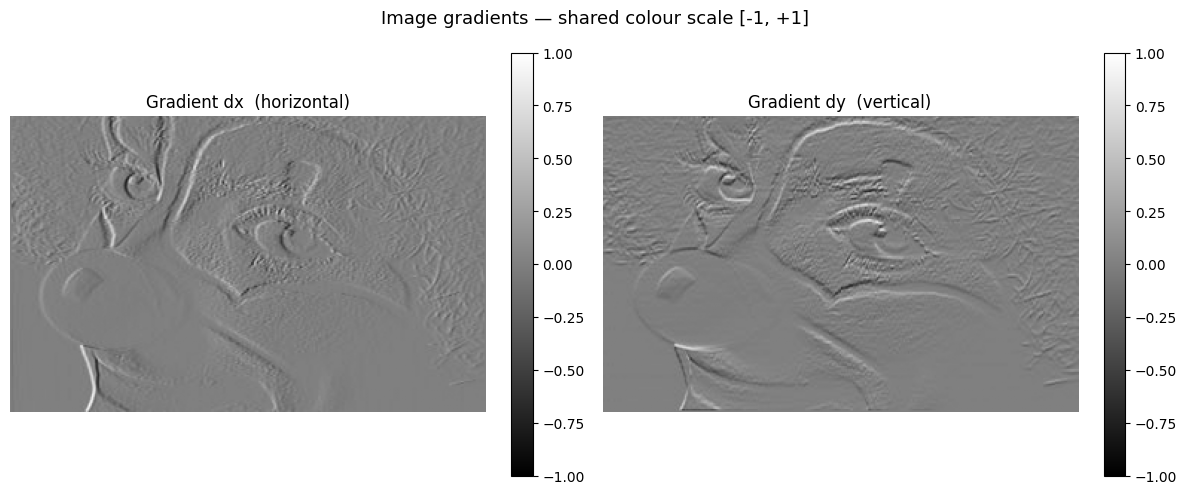


Problem:  The gradient images contain values in [-1, +1].
          Without an explicit vmin/vmax, imshow auto-scales each image
          independently, making them incomparable and clipping negatives.

Solution: Pass vmin=-1 and vmax=1 to both imshow calls so the grey-level
          mapping is identical for both images.



In [15]:
# TODO: load image
img = load_gray_normalized(image_path)

# TODO: define kernels
# dx kernel: shape (1, 3) — detects horizontal intensity changes
kernel_dx = np.array([[-1, 0, 1]], dtype=np.float64)
# dy kernel: shape (3, 1) — detects vertical intensity changes
kernel_dy = np.array([[-1], [0], [1]], dtype=np.float64)

# TODO: filter images
# cv2.filter2D: ddepth=-1 keeps the same depth as source (float64 here)
dx = cv2.filter2D(img, ddepth=-1, kernel=kernel_dx)
dy = cv2.filter2D(img, ddepth=-1, kernel=kernel_dy)

# TODO: display images
# ---- Problem & Solution -------------------------------------------------------
# Gradient values fall in [-1, +1]. Without explicit vmin/vmax, matplotlib
# auto-scales each image independently: negative values get clipped to black
# and the two images cannot be fairly compared.
#
# Solution: set vmin=-1, vmax=1 for both subplots so both images share the
# same symmetric colour scale centred on zero. Mid-grey = zero gradient,
# lighter = positive edge, darker = negative edge.
# ------------------------------------------------------------------------------
vmin, vmax = -1.0, 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(dx, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Gradient dx  (horizontal)')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(dy, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('Gradient dy  (vertical)')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.suptitle('Image gradients — shared colour scale [-1, +1]', fontsize=13)
plt.tight_layout()
plt.show()

print("""
Problem:  The gradient images contain values in [-1, +1].
          Without an explicit vmin/vmax, imshow auto-scales each image
          independently, making them incomparable and clipping negatives.

Solution: Pass vmin=-1 and vmax=1 to both imshow calls so the grey-level
          mapping is identical for both images.
""")

## Exercise 1.3
### Point operations
Download from the website the images `ueb131.png` and `ueb132.png`,
then load and display them.  
Both images illustrate two commonly encountered problems in photography.
Underexposed (overexposed) images are darker (brighter) than they should be,
because they have been exposed to too little (too much) light.

Compute and display the histograms (`plt.hist`,`np.flatten`) of the images in range $[0,1]$. Write a function `display_with_hist` that creates two subplots, showing the image and the respective histogram.

Can you identify the exposure problems in the histograms?
Hint: look at how the pixel intensities are distributed.

These defects can be corrected by remapping the pixel values to achieve a
more evenly distributed range of pixel intensities.
This can either be done by using histogram equalization (`cv2.equalizeHist`) or by using the logarithmic and power functions.

To use `cv2.equalizeHist`, the images need to be casted to uint8 in $[0,255]$. Write a function `normalized_to_uint8` to do this.

Apply the logarithmic and power to improve the two images. Experiment with different bases for the logarithm and power. To get a better feeling for the problem, plot the functions $x^2$ in $[0,1]$ and $log(x)$ in $[1,255]$ (why not $[0, 255]$?, `np.linspace, np.log, plt.plot`). **Where do the functions change quickly, where do they change slowly? How can you use this knowledge to improve the images?**

In [17]:
def display_with_hist(image):
    """
    Display a normalised grayscale image side-by-side with its histogram.

    Parameters
    ----------
    image : np.ndarray  (float, range [0, 1])
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Left: the image
    axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Image')
    axes[0].axis('off')

    # Right: pixel-intensity histogram
    # .flatten() converts the 2-D array to a 1-D list of all pixel values
    axes[1].hist(image.flatten(), bins=256, range=(0, 1),
                 color='steelblue', edgecolor='none')
    axes[1].set_title('Histogram')
    axes[1].set_xlabel('Pixel intensity')
    axes[1].set_ylabel('Count')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

In [18]:
def normalized_to_uint8(image):
    """
    Convert a normalised float image [0, 1] to uint8 [0, 255].
    Required because cv2.equalizeHist only accepts uint8 input.

    Parameters
    ----------
    image : np.ndarray  (float, range [0, 1])

    Returns
    -------
    np.ndarray  (uint8, range [0, 255])
    """
    return (image * 255).clip(0, 255).astype(np.uint8)

ueb131.png  (underexposed)


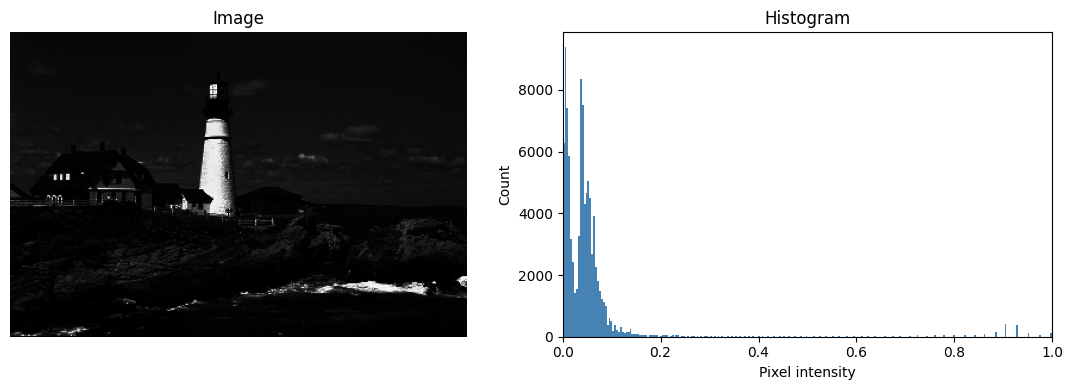

ueb132.png  (overexposed)


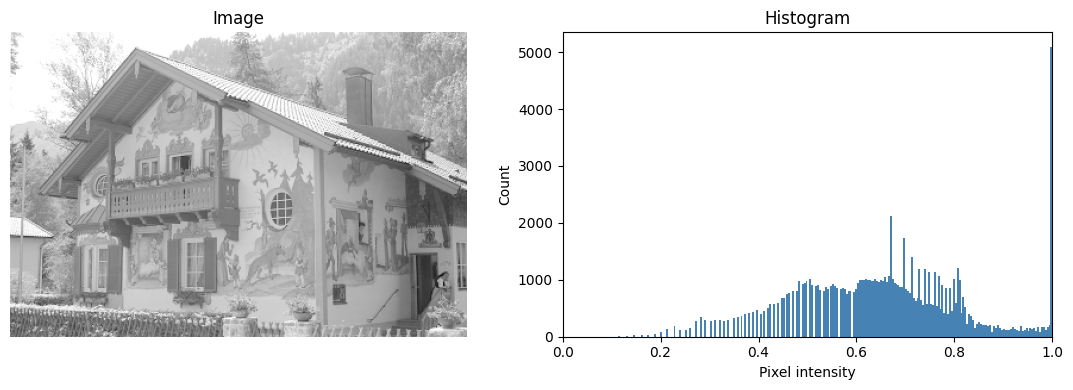


Identifying exposure problems from histograms
---------------------------------------------
Underexposed (ueb131): Histogram concentrated near 0 (dark end).
  Almost no pixels above ~0.5 — all detail is crushed into shadows.

Overexposed (ueb132): Histogram concentrated near 1 (bright end).
  Almost no pixels in darker half — highlights are clipped/washed out.



In [19]:
# TODO: load images
path_131 = join(getcwd(), 'data', 'exercise_1', 'ueb131.png')
path_132 = join(getcwd(), 'data', 'exercise_1', 'ueb132.png')

img131 = load_gray_normalized(path_131)   # underexposed (too dark)
img132 = load_gray_normalized(path_132)   # overexposed  (too bright)

# TODO: display images with histograms
print('ueb131.png  (underexposed)')
display_with_hist(img131)

print('ueb132.png  (overexposed)')
display_with_hist(img132)

print("""
Identifying exposure problems from histograms
---------------------------------------------
Underexposed (ueb131): Histogram concentrated near 0 (dark end).
  Almost no pixels above ~0.5 — all detail is crushed into shadows.

Overexposed (ueb132): Histogram concentrated near 1 (bright end).
  Almost no pixels in darker half — highlights are clipped/washed out.
""")

ueb131 — after histogram equalization


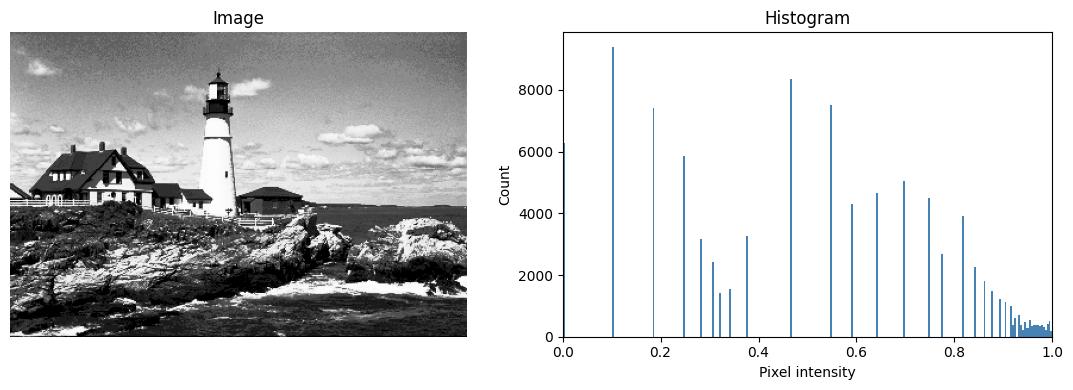

ueb132 — after histogram equalization


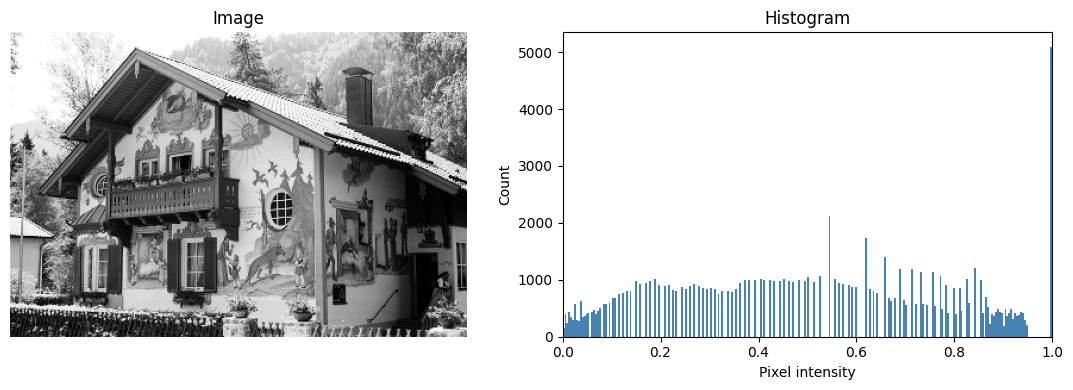

In [20]:
# TODO: convert images to uint8
img131_u8 = normalized_to_uint8(img131)
img132_u8 = normalized_to_uint8(img132)

# TODO: equalize histogram and display
img131_eq = cv2.equalizeHist(img131_u8).astype(np.float64) / 255.0
img132_eq = cv2.equalizeHist(img132_u8).astype(np.float64) / 255.0

print('ueb131 — after histogram equalization')
display_with_hist(img131_eq)

print('ueb132 — after histogram equalization')
display_with_hist(img132_eq)

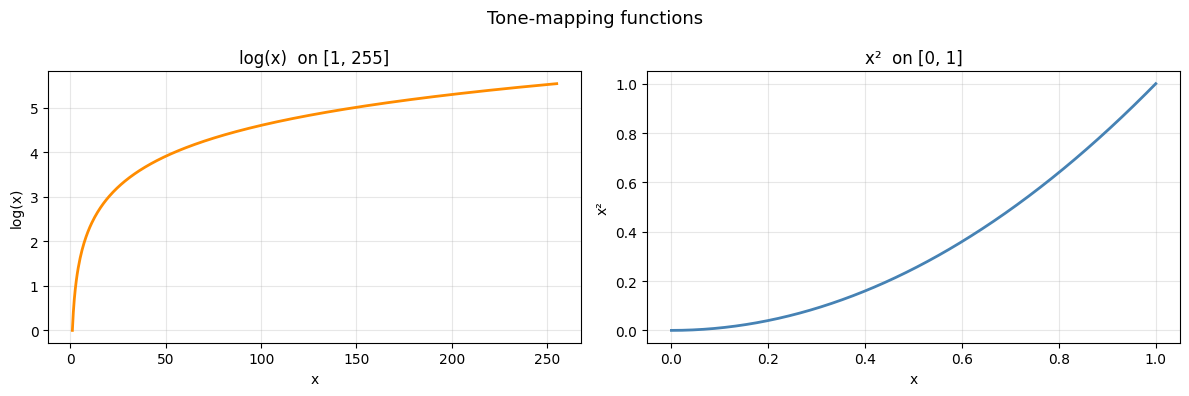


Interpretation
--------------
log(x):
  Changes fast for small x  -> dark values are stretched upward (brightened).
  Changes slowly for large x -> bright values are compressed.
  => Use log to BRIGHTEN an underexposed image.

x^2 (gamma > 1):
  Changes slowly for small x -> dark values left nearly unchanged.
  Changes fast for large x   -> bright values pulled toward white.
  => Use gamma > 1 to DARKEN an overexposed image.
     Use gamma < 1 (e.g. sqrt) to BRIGHTEN a dark image.



In [21]:
# TODO: display logarithmic function  (on [1, 255])
# Why not [0, 255]?  Because log(0) = -inf — undefined.
x_log = np.linspace(1, 255, 500)
y_log = np.log(x_log)

# TODO: display quadratic function  (on [0, 1])
x_pow = np.linspace(0, 1, 500)
y_pow = x_pow ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_log, y_log, color='darkorange', lw=2)
axes[0].set_title('log(x)  on [1, 255]')
axes[0].set_xlabel('x')
axes[0].set_ylabel('log(x)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_pow, y_pow, color='steelblue', lw=2)
axes[1].set_title('x²  on [0, 1]')
axes[1].set_xlabel('x')
axes[1].set_ylabel('x²')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Tone-mapping functions', fontsize=13)
plt.tight_layout()
plt.show()

print("""
Interpretation
--------------
log(x):
  Changes fast for small x  -> dark values are stretched upward (brightened).
  Changes slowly for large x -> bright values are compressed.
  => Use log to BRIGHTEN an underexposed image.

x^2 (gamma > 1):
  Changes slowly for small x -> dark values left nearly unchanged.
  Changes fast for large x   -> bright values pulled toward white.
  => Use gamma > 1 to DARKEN an overexposed image.
     Use gamma < 1 (e.g. sqrt) to BRIGHTEN a dark image.
""")

ueb131 — log transform (brightening underexposed image)


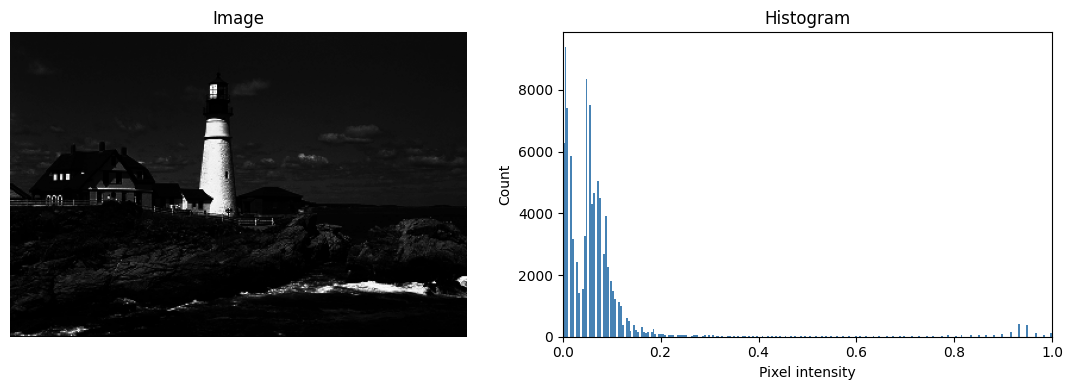

In [22]:
# TODO: transform and display ueb131.png  (underexposed -> apply log)

def log_transform(img):
    """
    Log transform: T(x) = log(1 + x) / log(2)
    Normalised so that x=1 maps to 1.
    Amplifies dark pixels, compresses bright pixels -> brightens image.
    """
    return (np.log1p(img) / np.log1p(1.0)).clip(0, 1)

img131_log = log_transform(img131)

print('ueb131 — log transform (brightening underexposed image)')
display_with_hist(img131_log)

ueb132 — power transform gamma=2 (darkening overexposed image)


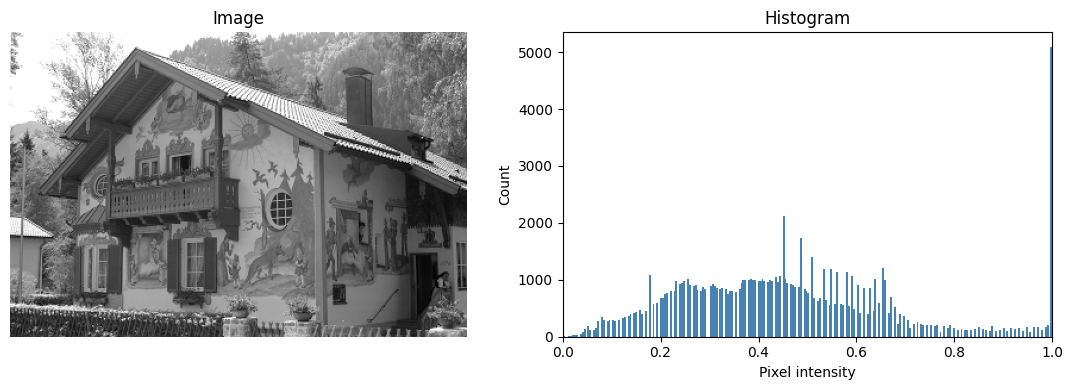

In [23]:
# TODO: transform and display ueb132.png  (overexposed -> apply power gamma > 1)

def power_transform(img, gamma=2.0):
    """
    Power (gamma) transform: T(x) = x^gamma
    gamma > 1 darkens (compresses bright values).
    gamma < 1 brightens (stretches dark values).
    """
    return np.power(img, gamma).clip(0, 1)

img132_pow = power_transform(img132, gamma=2.0)

print('ueb132 — power transform gamma=2 (darkening overexposed image)')
display_with_hist(img132_pow)